In [1]:
# Add imports
import urllib
import networkx as nx
import io
import json
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from itertools import islice
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import os
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from wordcloud import *

In [2]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f" Network loaded successfully!")
    print(f" Nodes: {network.number_of_nodes()}")
    print(f" Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"Error loading network: {str(e)}")
    network = None

 Network loaded successfully!
 Nodes: 11286
 Edges: 125705


In [9]:
# Find all Pope nodes
pope_nodes = set()
for node in network.nodes():
    name = network.nodes[node].get('NameURL', '')
    if 'Pope_' in name:
        pope_nodes.add(node)

Visualizing 263 Pope nodes in the network
Found 899 connections between Popes


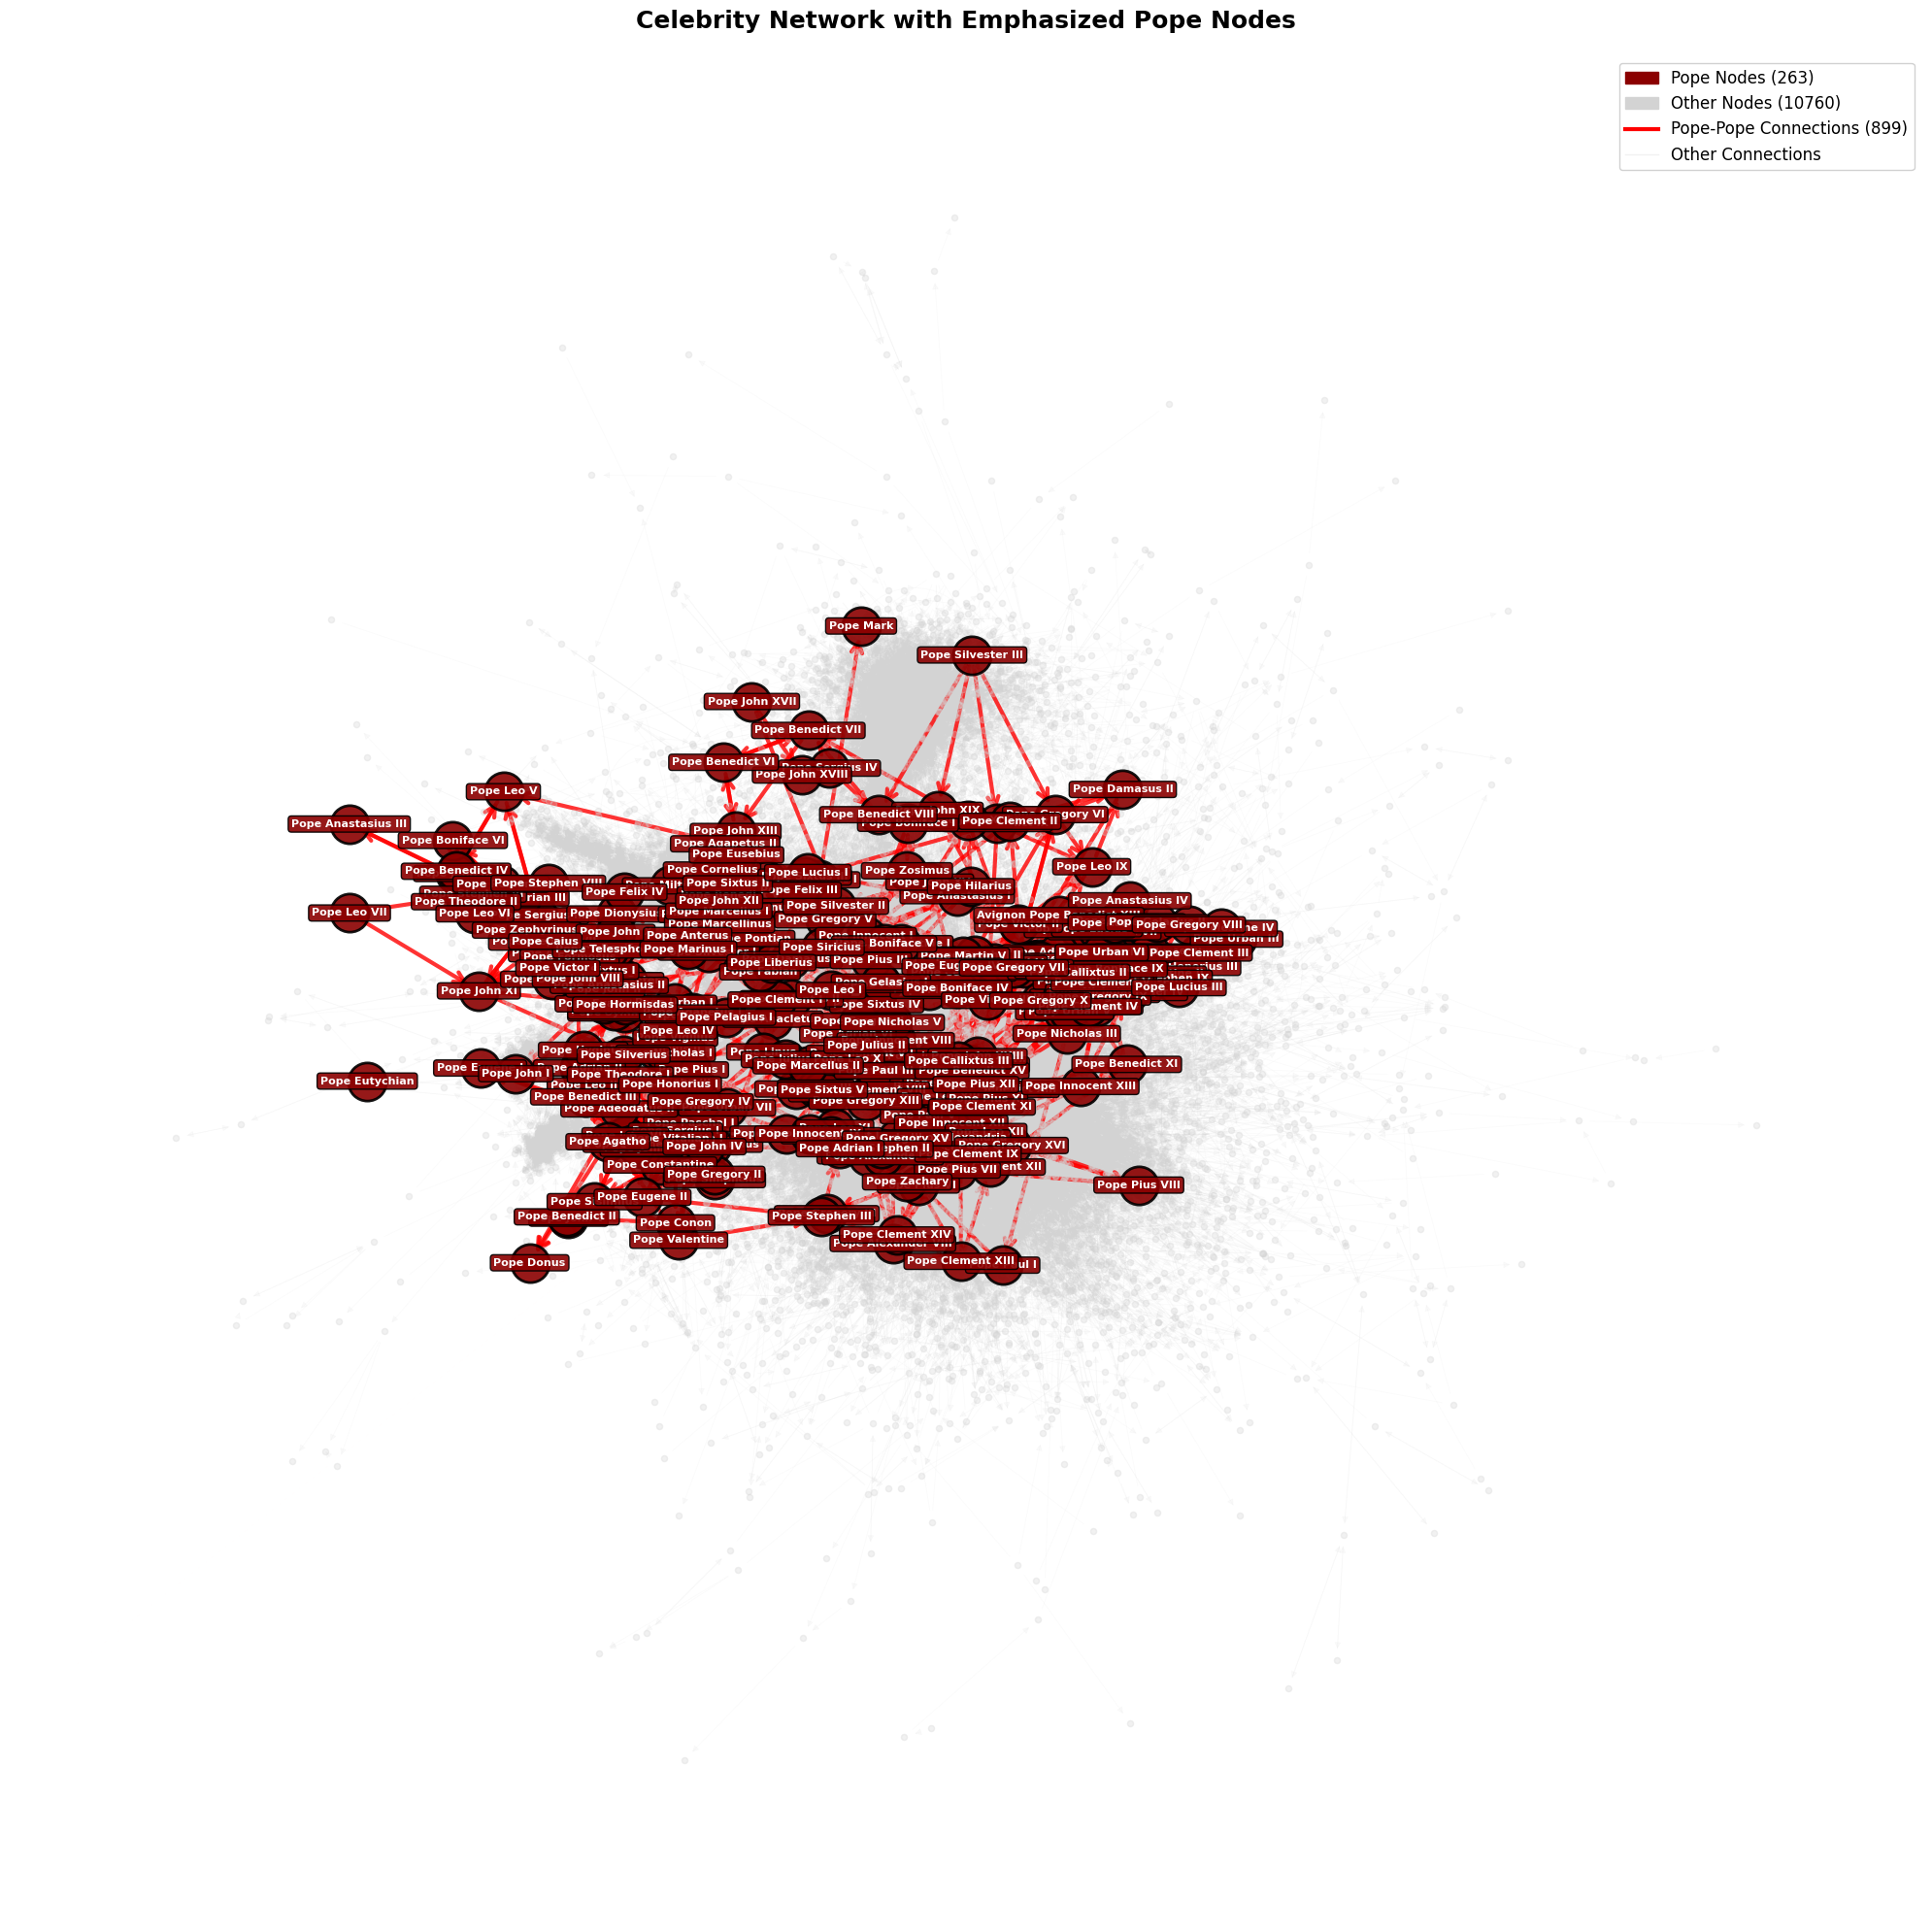


✓ Pope network visualization created and saved!


In [11]:
# Create visualization emphasizing Pope nodes
import matplotlib.patches as mpatches

# Get the largest connected component for better visualization
largest_cc = max(nx.connected_components(network.to_undirected()), key=len)
subgraph = network.subgraph(largest_cc).copy()

# Filter pope_nodes to only those in the subgraph
pope_nodes_in_subgraph = pope_nodes.intersection(set(subgraph.nodes()))

print(f"Visualizing {len(pope_nodes_in_subgraph)} Pope nodes in the network")

# Create figure
plt.figure(figsize=(20, 20))

# Use spring layout for better separation
pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)

# Separate nodes into Popes and non-Popes
non_pope_nodes = [n for n in subgraph.nodes() if n not in pope_nodes_in_subgraph]

# Draw non-Pope nodes (small, gray)
nx.draw_networkx_nodes(subgraph, pos, 
                       nodelist=non_pope_nodes,
                       node_color='lightgray',
                       node_size=20,
                       alpha=0.3)

# Draw Pope nodes (large, red)
nx.draw_networkx_nodes(subgraph, pos, 
                       nodelist=list(pope_nodes_in_subgraph),
                       node_color='darkred',
                       node_size=800,
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=2)

# Draw all edges (thin, light)
nx.draw_networkx_edges(subgraph, pos, 
                       edge_color='lightgray',
                       alpha=0.1,
                       width=0.5)

# Find and draw edges BETWEEN Pope nodes in a different color
pope_edges = [(u, v) for u, v in subgraph.edges() 
              if u in pope_nodes_in_subgraph and v in pope_nodes_in_subgraph]

if pope_edges:
    nx.draw_networkx_edges(subgraph, pos,
                          edgelist=pope_edges,
                          edge_color='red',
                          alpha=0.8,
                          width=3,
                          arrows=True,
                          arrowsize=20,
                          arrowstyle='->')
    print(f"Found {len(pope_edges)} connections between Popes")
else:
    print("No direct connections between Popes found")

# Add labels for Pope nodes only
pope_labels = {node: network.nodes[node].get('Name', node) 
               for node in pope_nodes_in_subgraph}

nx.draw_networkx_labels(subgraph, pos,
                       labels=pope_labels,
                       font_size=8,
                       font_weight='bold',
                       font_color='white',
                       bbox=dict(boxstyle='round,pad=0.3', 
                                facecolor='darkred', 
                                edgecolor='black',
                                alpha=0.9))

# Create legend
legend_elements = [
    mpatches.Patch(color='darkred', label=f'Pope Nodes ({len(pope_nodes_in_subgraph)})'),
    mpatches.Patch(color='lightgray', label=f'Other Nodes ({len(non_pope_nodes)})'),
    plt.Line2D([0], [0], color='red', linewidth=3, label=f'Pope-Pope Connections ({len(pope_edges)})'),
    plt.Line2D([0], [0], color='lightgray', linewidth=1, alpha=0.3, label='Other Connections')
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)

plt.title('Celebrity Network with Emphasized Pope Nodes', 
          fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Save the figure
plt.savefig('pope_network_visualization.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\n✓ Pope network visualization created and saved!")

In [ ]:
# Create visualization emphasizing Pope nodes with better separation
import matplotlib.patches as mpatches

# Get the largest connected component for better visualization
largest_cc = max(nx.connected_components(network.to_undirected()), key=len)
subgraph = network.subgraph(largest_cc).copy()

# Filter pope_nodes to only those in the subgraph
pope_nodes_in_subgraph = pope_nodes.intersection(set(subgraph.nodes()))

print(f"Visualizing {len(pope_nodes_in_subgraph)} Pope nodes in the network")

# Create figure
plt.figure(figsize=(24, 24))

# Use spring layout with higher k value for more spacing
pos = nx.spring_layout(subgraph, k=1.5, iterations=100, seed=42)

# Apply additional repulsion specifically to Pope nodes
# Create a subgraph of just Pope nodes to spread them out
if len(pope_nodes_in_subgraph) > 1:
    pope_subgraph = subgraph.subgraph(pope_nodes_in_subgraph).copy()
    pope_pos = nx.spring_layout(pope_subgraph, k=3.0, iterations=100, seed=42, scale=2.0)
    
    # Update positions for Pope nodes
    for node in pope_nodes_in_subgraph:
        if node in pope_pos:
            pos[node] = pope_pos[node]

# Separate nodes into Popes and non-Popes
non_pope_nodes = [n for n in subgraph.nodes() if n not in pope_nodes_in_subgraph]

# Draw non-Pope nodes (small, gray)
nx.draw_networkx_nodes(subgraph, pos, 
                       nodelist=non_pope_nodes,
                       node_color='lightgray',
                       node_size=20,
                       alpha=0.3)

# Draw Pope nodes (large, red)
nx.draw_networkx_nodes(subgraph, pos, 
                       nodelist=list(pope_nodes_in_subgraph),
                       node_color='darkred',
                       node_size=1200,
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=2)

# Draw all edges (thin, light)
nx.draw_networkx_edges(subgraph, pos, 
                       edge_color='lightgray',
                       alpha=0.08,
                       width=0.3)

# Find and draw edges BETWEEN Pope nodes in a different color
pope_edges = [(u, v) for u, v in subgraph.edges() 
              if u in pope_nodes_in_subgraph and v in pope_nodes_in_subgraph]

if pope_edges:
    nx.draw_networkx_edges(subgraph, pos,
                          edgelist=pope_edges,
                          edge_color='red',
                          alpha=0.8,
                          width=4,
                          arrows=True,
                          arrowsize=25,
                          arrowstyle='->')
    print(f"Found {len(pope_edges)} connections between Popes")
else:
    print("No direct connections between Popes found")

# Create legend
legend_elements = [
    mpatches.Patch(color='darkred', label=f'Pope Nodes ({len(pope_nodes_in_subgraph)})'),
    mpatches.Patch(color='lightgray', label=f'Other Nodes ({len(non_pope_nodes)})'),
    plt.Line2D([0], [0], color='red', linewidth=4, label=f'Pope-Pope Connections ({len(pope_edges)})'),
    plt.Line2D([0], [0], color='lightgray', linewidth=1, alpha=0.3, label='Other Connections')
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=14, framealpha=0.9)

plt.title('Celebrity Network with Emphasized Pope Nodes', 
          fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

# Save the figure
plt.savefig('pope_network_visualization.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\n✓ Pope network visualization created and saved!")